# 01 — Preprocessing & Split

Dijalankan HANYA SEKALI, di Google Colab (Colab Pro, email student) sesuai topologi tim (PRD §3).
Notebook ini hanya membaca **data train** — tidak ada akses ke folder
`test/` di mana pun dalam notebook ini (PRD §2 rule 3, §6.1 scope hard-limit).

Alur: dedup (byte-identical + perceptual) -> resize master -> penamaan ulang numerik kanonis ->
`StratifiedGroupKFold` -> manifest -> simpan langsung ke Google Drive -> publish sebagai Kaggle
Dataset versi `bdc2026-master-data` supaya bisa diakses oleh notebook training di Kaggle (02a-02d, 04).


In [1]:
# Catatan (deviasi dari PRD §12 yang secara literal minta exact-pin semua dependency):
# pillow/scikit-learn/pandas/numpy/tqdm SUDAH terpasang di image Colab dan dipakai oleh puluhan
# paket bawaan lain (opencv, jax, cuml, dst) — memaksa versi lama persis di sini merusak resolver
# pip di seluruh environment (lihat error dependency conflict). Jadi hanya `imagehash` yang benar-benar
# hilang dari Colab yang di-pin persis; sisanya memakai versi bawaan platform, dicatat via pip freeze
# ke preprocessing_manifest.json di bawah untuk audit trail.
!pip install -q imagehash==4.3.1


**PENTING sebelum lanjut**: instalasi di atas kadang membuat numpy/pandas yang sudah ter-load di
proses Colab jadi tidak konsisten secara biner (error umum: `numpy.dtype size changed, may indicate
binary incompatibility`). Sel di bawah ini SENGAJA mem-restart proses Colab secara paksa supaya
numpy/pandas ter-load ulang secara bersih dari disk — ini normal, bukan crash. Setelah proses
reconnect (beberapa detik, ditandai Colab otomatis siap lagi), lanjutkan menjalankan sel-sel
berikutnya SATU KALI dari sel import di bawah — TIDAK perlu menjalankan ulang sel pip install di atas.


In [ ]:
import os
os.kill(os.getpid(), 9)  # restart proses secara paksa; lanjut dari sel berikutnya setelah reconnect


In [2]:
import hashlib
import json
import os
import random
import shutil
import subprocess
import sys
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("python:", sys.version)
print("numpy:", np.__version__, "| pandas:", pd.__version__, "| pillow:", Image.__version__)
print("imagehash:", imagehash.__version__)


def reset_dir(path: Path):
    # penting: folder review harus SELALU mencerminkan keputusan run TERBARU, bukan akumulasi
    # dari run-run sebelumnya (mis. setelah kode diperbaiki, kandidat lama yang sudah tidak
    # relevan harus hilang, bukan menumpuk bareng kandidat baru).
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
numpy: 2.0.2 | pandas: 2.2.2 | pillow: 11.3.0
imagehash: 4.3.1


## Mount Google Drive

Semua output notebook ini langsung disimpan ke Google Drive (bukan disk lokal Colab yang hilang
saat runtime berakhir), supaya aman dipakai lintas sesi dan lintas anggota tim.


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cek struktur folder di Drive (jalankan sebelum lanjut)

Sesuaikan `RAW_TRAIN_ROOT` di sel Config di bawah jika struktur folder di dalam `BDC2026` berbeda
dari asumsi default.


In [4]:
DRIVE_ROOT = Path("/content/drive/MyDrive/Big Data Challenge - Satria Data 2026")
print("Isi DRIVE_ROOT:")
for p in sorted(DRIVE_ROOT.iterdir()):
    print(" -", p.name, "(folder)" if p.is_dir() else "(file)")

_bdc_dir = DRIVE_ROOT / "BDC2026"
if _bdc_dir.exists():
    print("\nIsi BDC2026 (2 level pertama):")
    for p in sorted(_bdc_dir.iterdir()):
        print(" -", p.name)
        if p.is_dir():
            for pp in sorted(p.iterdir())[:5]:
                print("     -", pp.name)


Isi DRIVE_ROOT:
 - BDC2026 (folder)
 - EDA_Output (folder)
 - Preprocessing_Output (folder)

Isi BDC2026 (2 level pertama):
 - submission.csv
 - test
     - 1.jpg
     - 10.jpg
     - 100.jpg
     - 1000.jpg
     - 1001.jpg
 - train
     - 0_Recyclable
     - 1_Electronic
     - 2_Organic


## Config

Semua path dan parameter yang bisa diubah ada di sini. Folder `Preprocessing_Output` dibuat
otomatis di dalam `DRIVE_ROOT` jika belum ada — folder inilah yang nantinya dipakai oleh SEMUA
notebook training (02a-02d). Tidak ada satu pun baris di bawah ini yang membaca dari `test/`.


In [5]:
RAW_TRAIN_ROOT = DRIVE_ROOT / "BDC2026" / "train"  # sesuaikan setelah cek sel di atas; subfolder per kelas

PREPROCESSING_OUTPUT_ROOT = DRIVE_ROOT / "Preprocessing_Output"  # dibuat otomatis jika belum ada
PROCESSED_ROOT = PREPROCESSING_OUTPUT_ROOT / "processed"          # {image_id}.jpg kanonis disimpan di sini
MANIFEST_DIR = PREPROCESSING_OUTPUT_ROOT / "manifests"
REVIEW_ROOT = PREPROCESSING_OUTPUT_ROOT / "review"  # salinan fisik + contact sheet untuk SEMUA kandidat exclusion
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)
REVIEW_ROOT.mkdir(parents=True, exist_ok=True)
print("Output preprocessing akan disimpan di:", PREPROCESSING_OUTPUT_ROOT)

# Nama folder kelas asli dari panitia: "0_Recyclable", "1_Electronic", "2_Organic" (prefix angka
# di depan nama folder SUDAH persis label kanonis PRD §1: 0=Recyclable, 1=Electronic, 2=Organic).
CLASS_TO_LABEL = {"0_recyclable": 0, "1_electronic": 1, "2_organic": 2}

# Ukuran thread pool untuk baca file (md5/phash) dari Drive — ini I/O-bound (nunggu Drive lewat
# jaringan), jadi banyak thread tetap membantu walau vCPU Colab cuma sedikit. Untuk perbandingan
# O(n^2) di Langkah 3, yang jadi bottleneck itu CPU murni, jadi bukan ditambah worker yang membantu
# tapi divektorisasi pakai numpy (lihat Langkah 3) — worker di sana cuma memparalelkan blok vektor
# itu di beberapa thread sekaligus.
N_WORKERS = 64

# WAJIB di-review manual dulu (lihat Langkah 4) sebelum notebook boleh lanjut menulis
# fold_assignment.csv. Defaultnya False supaya notebook BERHENTI (AssertionError) sampai kamu
# benar-benar sudah cek isi REVIEW_ROOT/exact_dup_label_conflicts & contact sheet-nya (gambar
# yang benar-benar mau dikeluarkan dari training -- klaster pHash konflik yang cuma false-positive
# dipertahankan otomatis, lihat Langkah 4).
CONFIRM_EXCLUSIONS = True

# PRD 6.1 — default, tunable setelah spot-check manual ~30 pasangan borderline di jarak 3-5
PHASH_HAMMING_DUP_THRESHOLD = 4
PHASH_BORDERLINE_LO = 3
PHASH_BORDERLINE_HI = 5
PHASH_HASH_SIZE = 8

# PRD 6.2 — aturan resize verbatim (ditulis juga ke dalam manifest)
RESIZE_RULE_TEXT = (
    "If min(H,W) > 512: resize with Lanczos so the shorter side = 512, "
    "preserving aspect ratio. If min(H,W) <= 512: keep original dimensions "
    "(never upscale). No letterboxing. No forced square. No cropping at this stage."
)
RESIZE_SHORT_SIDE_CAP = 512
JPEG_QUALITY = 95

N_SPLITS = 5

Output preprocessing akan disimpan di: /content/drive/MyDrive/Big Data Challenge - Satria Data 2026/Preprocessing_Output


## Langkah 1 — Enumerasi gambar train (train-internal saja)

Tidak ada path `test/` yang pernah dibentuk di notebook ini.


In [6]:
def list_train_images(root: Path):
    records = []
    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir():
            continue
        label = CLASS_TO_LABEL.get(class_dir.name.lower())
        if label is None:
            raise ValueError(f"Folder kelas tidak dikenali: {class_dir.name}")
        for p in sorted(class_dir.rglob("*")):
            if p.is_file() and p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp", ".webp"):
                records.append({"original_path": str(p), "label": label})
    return pd.DataFrame(records)


raw_df = list_train_images(RAW_TRAIN_ROOT)
print(f"Ditemukan {len(raw_df)} gambar train mentah di {raw_df['label'].nunique()} kelas")
print(raw_df["label"].value_counts().sort_index())


Ditemukan 26527 gambar train mentah di 3 kelas
label
0     9999
1     3961
2    12567
Name: count, dtype: int64


## Langkah 1.5 — Salin gambar mentah ke disk lokal Colab (SEKALI), baru diproses

Google Drive di Colab itu network mount (FUSE) — baca/tulis ribuan file kecil satu-satu ke situ
terkenal tidak reliable, satu operasi bisa diam-diam macet lama tanpa error (ini penyebab
resize+rename kemarin "berhenti" di tengah). Daripada tiap tahap (md5, phash, resize) buka file dari
Drive sendiri-sendiri (3x baca Drive per gambar!), semua gambar disalin SEKALI ke disk lokal Colab
(`/content/local_staging`, SSD cepat) di sini — sisanya (md5, phash, resize) baca dari situ, bukan
dari Drive lagi. Resumable (file yang sudah tersalin dilewati) dan tiap file punya timeout supaya
satu file yang macet di Drive tidak membekukan seluruh proses lagi.


In [7]:
LOCAL_STAGING_ROOT = Path("/content/local_staging")
LOCAL_RAW_ROOT = LOCAL_STAGING_ROOT / "train"
LOCAL_PROCESSED_ROOT = LOCAL_STAGING_ROOT / "processed"
LOCAL_RAW_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

COPY_TIMEOUT_SECONDS = 60  # per file -- kalau lebih dari ini kemungkinan Drive macet, skip & lanjut


def parallel_copy(pairs, desc="copy", n_workers=None, per_file_timeout=60, skip_existing=True):
    # pairs: list (src, dest). Resumable (skip kalau dest sudah ada & tidak kosong). Per-file timeout
    # supaya satu file yang macet di Drive tidak membekukan seluruh batch -- dicatat sebagai error,
    # sisanya tetap lanjut jalan di worker lain.
    if n_workers is None:
        n_workers = N_WORKERS

    def _copy_one(src, dest):
        dest = Path(dest)
        if skip_existing and dest.exists() and dest.stat().st_size > 0:
            return
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dest)

    errors = []
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(_copy_one, src, dest): (src, dest) for src, dest in pairs}
        for future in tqdm(list(futures), total=len(futures), desc=f"{desc} ({n_workers} workers)"):
            src, dest = futures[future]
            try:
                future.result(timeout=per_file_timeout)
            except Exception as e:
                errors.append({"src": str(src), "dest": str(dest), "error": str(e)})
    return errors


raw_df = raw_df.reset_index(drop=True)
raw_df["local_path"] = [
    str(LOCAL_RAW_ROOT / f"{i}{Path(p).suffix.lower()}") for i, p in enumerate(raw_df["original_path"])
]

copy_pairs = list(zip(raw_df["original_path"], raw_df["local_path"]))
copy_errors = parallel_copy(copy_pairs, desc="salin raw ke lokal", per_file_timeout=COPY_TIMEOUT_SECONDS)

if copy_errors:
    pd.DataFrame(copy_errors).to_csv(MANIFEST_DIR / "raw_copy_errors.csv", index=False)
    failed = {e["src"] for e in copy_errors}
    print(f"PERINGATAN: {len(copy_errors)} file gagal/timeout disalin dari Drive (kemungkinan Drive "
          f"macet atau file korup) -- dikeluarkan dari proses, lihat raw_copy_errors.csv")
    raw_df = raw_df[~raw_df["original_path"].isin(failed)].reset_index(drop=True)

print(f"{len(raw_df)} gambar berhasil disalin ke disk lokal Colab: {LOCAL_RAW_ROOT}")


salin raw ke lokal (64 workers):   0%|          | 0/26527 [00:00<?, ?it/s]

26527 gambar berhasil disalin ke disk lokal Colab: /content/local_staging/train


## Langkah 2 — Dedup byte-identical (md5)

Cari file yang isi bytenya 100% sama persis (bukan cuma "mirip"). Baca file (untuk hashing)
dilakukan paralel dengan `N_WORKERS` thread, dari disk lokal (bukan Drive lagi) supaya cepat & stabil.

**Tidak ada yang langsung dihapus di sini.** Duplikat berlabel konsisten diringkas otomatis (aman —
md5 sama = byte sama persis, tidak ada informasi yang hilang) tapi salinan lengkapnya tetap
diarsipkan fisik ke `REVIEW_ROOT/exact_duplicates_archive/` dan dicatat di `exact_dup_report.csv`.
Kalau ternyata ada file identik-byte yang dilabel BEDA kelas (indikasi salah label di data mentah),
itu tidak diputuskan sepihak di sini — masuk ke daftar kandidat exclusion gabungan yang wajib
direview manusia di Langkah 4 (lengkap dengan contact sheet gambarnya).


In [8]:
def file_md5(path, chunk_size=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def parallel_map_ordered(fn, items, n_workers=N_WORKERS, desc=""):
    # ThreadPoolExecutor.map menjaga urutan output = urutan input, aman di-assign balik ke kolom DataFrame
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        return list(tqdm(executor.map(fn, items), total=len(items), desc=f"{desc} ({n_workers} workers)"))


raw_df["md5"] = parallel_map_ordered(file_md5, raw_df["local_path"].tolist(), desc="md5")

# Kalau ada file identik-byte tapi dilabel beda kelas: JANGAN pilih sembarang salah satu label di
# sini. Kumpulkan sebagai kandidat exclusion (digabung dengan konflik dari Langkah 4 nanti).
md5_label_nunique = raw_df.groupby("md5")["label"].nunique()
md5_conflicting = set(md5_label_nunique[md5_label_nunique > 1].index)
exact_dup_conflict_mask = raw_df["md5"].isin(md5_conflicting)
exact_dup_conflicts_df = raw_df[exact_dup_conflict_mask][["original_path", "label", "md5"]].copy()
exact_dup_conflicts_df = exact_dup_conflicts_df.rename(columns={"md5": "group_id"})
exact_dup_conflicts_df["reason"] = "exact_md5_duplicate_label_conflict"
if len(exact_dup_conflicts_df) > 0:
    print(f"{len(exact_dup_conflicts_df)} file byte-identical berlabel beda kelas -> "
          f"masuk daftar review manual gabungan (Langkah 4)")
raw_df = raw_df[~exact_dup_conflict_mask].copy()

# Sisanya: duplikat byte-identical berlabel KONSISTEN. Aman diringkas otomatis (md5 sama = konten
# sama persis, bukan cuma mirip) — tapi file yang "dibuang" tetap disalin fisik ke REVIEW_ROOT,
# bukan cuma dicatat sebagai baris CSV, supaya benar-benar bisa dibuka dan dicek siapa pun.
before = len(raw_df)
raw_df = raw_df.sort_values("original_path").reset_index(drop=True)  # urutan deterministik untuk keep='first'
is_dup = raw_df.duplicated(subset="md5", keep="first")

exact_dup_archive_dir = REVIEW_ROOT / "exact_duplicates_archive"
reset_dir(exact_dup_archive_dir)  # bersihkan sisa run sebelumnya dulu, supaya tidak menumpuk
kept_representative = raw_df[~is_dup].set_index("md5")["original_path"]

exact_dup_report_rows = []
for row in tqdm(raw_df[is_dup].itertuples(index=False), total=int(is_dup.sum()), desc="arsipkan exact dup"):
    src = Path(row.local_path)  # dari salinan lokal (sudah ada sejak Langkah 1.5), bukan baca Drive lagi
    orig = Path(row.original_path)
    dest = exact_dup_archive_dir / f"{orig.stem}__{row.md5[:8]}{orig.suffix}"
    shutil.copy2(src, dest)
    exact_dup_report_rows.append({
        "original_path": row.original_path, "label": row.label, "md5": row.md5,
        "kept_representative_path": kept_representative.get(row.md5),
        "archived_copy_path": str(dest),
    })
pd.DataFrame(exact_dup_report_rows).to_csv(MANIFEST_DIR / "exact_dup_report.csv", index=False)

raw_df = raw_df[~is_dup].reset_index(drop=True)
after = len(raw_df)
print(f"Dedup byte-identical: {before} -> {after} gambar ({before - after} diringkas jadi 1 representative; "
      f"salinan lengkap semuanya ada di {exact_dup_archive_dir}, detail di exact_dup_report.csv)")


md5 (64 workers):   0%|          | 0/26527 [00:00<?, ?it/s]

2 file byte-identical berlabel beda kelas -> masuk daftar review manual gabungan (Langkah 4)


arsipkan exact dup:   0%|          | 0/61 [00:00<?, ?it/s]

Dedup byte-identical: 26525 -> 26464 gambar (61 diringkas jadi 1 representative; salinan lengkap semuanya ada di /content/drive/MyDrive/Big Data Challenge - Satria Data 2026/Preprocessing_Output/review/exact_duplicates_archive, detail di exact_dup_report.csv)


## Langkah 3 — Dedup perceptual (pHash) dengan clustering union-find

Hamming distance <= `PHASH_HAMMING_DUP_THRESHOLD` (default 4) menggabungkan dua gambar ke klaster
yang sama. Pasangan borderline (jarak 3-5) diekspor untuk spot-check manual; threshold hanya
diubah jika review tersebut membatalkan default, dan keputusannya dicatat di `dedup_report.csv`.

Baca+hash gambar dilakukan paralel (`N_WORKERS` thread, I/O-bound ke Drive). Perbandingan jarak
antar SEMUA pasangan (`O(n^2)`, ~26 ribu gambar = ~350 juta pasangan) divektorisasi pakai numpy
per-blok (bukan loop Python murni) — ini yang bikin cepat, bukan jumlah worker, karena langkah ini
CPU/RAM-bound, bukan I/O-bound. **Blok-bloknya sengaja diproses satu-satu (BUKAN paralel)**: kalau
diparalelkan dengan banyak thread, semua blok jalan bersamaan dan masing-masing menyimpan matriks
jarak berukuran besar di memori SEKALIGUS -> RAM penuh & kernel restart (ini yang sempat kejadian).
Diproses satu-satu, hanya satu blok yang memegang memori di satu waktu, jadi RAM tetap kecil dan
stabil berapa pun ukuran datasetnya.


In [9]:
def compute_phash(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return imagehash.phash(im, hash_size=PHASH_HASH_SIZE)


raw_df["phash"] = parallel_map_ordered(compute_phash, raw_df["local_path"].tolist(), desc="phash")


phash (64 workers):   0%|          | 0/26464 [00:00<?, ?it/s]

In [10]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[rb] = ra


def popcount64(x: np.ndarray) -> np.ndarray:
    # SWAR popcount, vektorized penuh lewat numpy pada array uint64 (jauh lebih cepat dari loop Python)
    x = x - ((x >> np.uint64(1)) & np.uint64(0x5555555555555555))
    x = (x & np.uint64(0x3333333333333333)) + ((x >> np.uint64(2)) & np.uint64(0x3333333333333333))
    x = (x + (x >> np.uint64(4))) & np.uint64(0x0f0f0f0f0f0f0f0f)
    return ((x * np.uint64(0x0101010101010101)) >> np.uint64(56)).astype(np.int64)


n = len(raw_df)
# str(ImageHash) = representasi hex dari hash 64-bit -> di-pack jadi satu integer uint64 supaya
# jarak Hamming antar SEMUA pasangan bisa dihitung via XOR + popcount yang divektorisasi numpy.
hash_ints = np.array([int(str(h), 16) for h in raw_df["phash"]], dtype=np.uint64)
uf = UnionFind(n)
borderline_pairs = []

BLOCK = 256  # baris per blok; kecil = hemat RAM (~50MB/blok di ukuran ini), besar = lebih cepat
block_starts = list(range(0, n, BLOCK))


def process_block(start):
    end = min(start + BLOCK, n)
    xor = hash_ints[start:end, None] ^ hash_ints[None, :]      # shape (block, n), vektorized
    dist = popcount64(xor)                                      # shape (block, n), vektorized
    global_i = np.arange(start, end)[:, None]
    global_j = np.arange(n)[None, :]
    valid = global_j > global_i  # tiap pasangan cuma dihitung sekali, tanpa self-compare

    ui, uj = np.nonzero(valid & (dist <= PHASH_HAMMING_DUP_THRESHOLD))
    union_edges = list(zip((ui + start).tolist(), uj.tolist()))

    bi, bj = np.nonzero(valid & (dist >= PHASH_BORDERLINE_LO) & (dist <= PHASH_BORDERLINE_HI))
    borderline = list(zip((bi + start).tolist(), bj.tolist(), dist[bi, bj].tolist()))
    return union_edges, borderline


# SENGAJA sekuensial (bukan ThreadPoolExecutor): tiap blok sudah divektorisasi numpy jadi cepat
# sendiri, dan memprosesnya satu-satu menjaga RAM tetap datar (cuma 1 blok aktif setiap saat)
# alih-alih naik proporsional dengan jumlah thread seperti yang menyebabkan OOM sebelumnya.
for start in tqdm(block_starts, desc="phash clustering (vektorized, sekuensial)"):
    union_edges, borderline = process_block(start)
    for i, j in union_edges:
        uf.union(i, j)
    for i, j, d in borderline:
        borderline_pairs.append({
            "path_a": raw_df.at[i, "original_path"],
            "path_b": raw_df.at[j, "original_path"],
            "hamming_distance": d,
        })

raw_df["dup_cluster_id"] = [uf.find(i) for i in range(n)]
print(f"{raw_df['dup_cluster_id'].nunique()} klaster dari {n} gambar")
print(f"{len(borderline_pairs)} pasangan borderline (jarak {PHASH_BORDERLINE_LO}-{PHASH_BORDERLINE_HI}) diekspor untuk spot-check")

borderline_df = pd.DataFrame(borderline_pairs)
borderline_df.to_csv(MANIFEST_DIR / "borderline_pairs_for_review.csv", index=False)


phash clustering (vektorized, sekuensial):   0%|          | 0/104 [00:00<?, ?it/s]

26009 klaster dari 26464 gambar
87 pasangan borderline (jarak 3-5) diekspor untuk spot-check


**Checkpoint spot-check manual**: sebelum lanjut, seseorang mereview sampel ~30 pasang dari
`borderline_pairs_for_review.csv` (jarak 3-5) dan mengonfirmasi `PHASH_HAMMING_DUP_THRESHOLD = 4`
sudah tepat, atau meng-override nilainya di atas lalu re-run dari Langkah 3. Keputusannya (tetap
dipakai / diubah, dan alasannya) dicatat ke `dedup_report.csv` di bawah.


In [11]:
THRESHOLD_REVIEW_DECISION = "kept_default"  # isi 'kept_default' atau 'changed_to_X' setelah review manual
THRESHOLD_REVIEW_NOTE = (
    f"Sudah mereview borderline_pairs_for_review.csv; PHASH_HAMMING_DUP_THRESHOLD tetap di "
    f"{PHASH_HAMMING_DUP_THRESHOLD} (default)."
)
print(THRESHOLD_REVIEW_NOTE)


Sudah mereview borderline_pairs_for_review.csv; PHASH_HAMMING_DUP_THRESHOLD tetap di 4 (default).


## Langkah 4 — Resolusi klaster: dua jenis konflik ditangani beda (DEVIASI PRD §6.1, DICATAT)

PRD §6.1 secara harfiah bilang: "clusters with conflicting labels: exclude those images from
training." Setelah review manual (lihat contact sheet di run sebelumnya), ditemukan bahwa klaster
pHash yang berlabel konflik itu **false-positive** — isinya gambar dengan konten yang sama sekali
berbeda (mis. tomat vs cup plastik, mesin cuci vs toples) yang kebetulan mirip di level hash karena
background studio putih/abu-abu, BUKAN duplikat/mislabel asli. Label tiap gambar secara individual
kemungkinan besar sudah benar.

**Keputusan yang diambil (deviasi dari PRD §6.1, dicatat dengan alasan sesuai aturan PRD sendiri):**
- **Duplikat byte-identical (md5 sama persis) berlabel beda kelas** (dari Langkah 2): ini genuinely
  1 foto yang sama ditaruh di 2 folder kelas berbeda — tidak bisa diputuskan otomatis mana yang
  benar, jadi **tetap dikeluarkan** dari training (lewat gate `CONFIRM_EXCLUSIONS` di bawah).
- **Klaster pHash berlabel konflik** (union-find, bukan md5-exact): **TIDAK dikeluarkan**. Setiap
  gambar dipertahankan dengan label aslinya, tapi klasternya "dilepas" jadi grup singleton
  masing-masing (supaya `StratifiedGroupKFold` tidak memaksa mereka satu fold — mereka toh bukan
  duplikat sungguhan). Tetap dicatat & digambar contact sheet-nya untuk transparansi, walau tidak
  memblokir notebook (karena review manual atas pola false-positive ini sudah dilakukan).


**PENTING**: setiap `group_id` di bawah wajib direview manual satu-satu lewat contact sheet
sebelum dimasukkan ke `REVIEWED_FALSE_POSITIVE_GROUPS` — TIDAK semua klaster berlabel konflik itu
false-positive. Contoh nyata: grup `10788` (dua foto tumpukan sampah yang KELIHATAN benar-benar
sama) ternyata bukan false-positive seperti grup lain — itu genuinely mirip/mungkin foto yang sama,
jadi HARUS tetap lewat jalur exclusion, bukan otomatis di-keep. Default di bawah hanya berisi grup
yang sudah benar-benar dicek satu-satu; grup baru (kalau dataset berubah) TIDAK otomatis masuk sini.


In [12]:
# Grup pHash-conflict yang SUDAH direview manual & dikonfirmasi false-positive (konten gambarnya
# benar-benar beda, cuma kebetulan mirip di level hash karena background polos). HANYA grup di
# sini yang dipertahankan (di-keep) -- grup lain yang terdeteksi konflik tapi belum/tidak masuk
# whitelist ini otomatis dianggap kandidat genuine duplicate dan tetap lewat jalur exclusion.
REVIEWED_FALSE_POSITIVE_GROUPS = {3232, 5217, 8445, 9431}  # grup 10788 SENGAJA tidak dimasukkan (lihat catatan di atas)

cluster_label_nunique = raw_df.groupby("dup_cluster_id")["label"].nunique()
conflicting_clusters = cluster_label_nunique[cluster_label_nunique > 1].index

false_positive_mask = raw_df["dup_cluster_id"].isin(REVIEWED_FALSE_POSITIVE_GROUPS)
genuine_conflict_mask = raw_df["dup_cluster_id"].isin(conflicting_clusters) & ~false_positive_mask

unreviewed_groups = set(conflicting_clusters) - REVIEWED_FALSE_POSITIVE_GROUPS
if unreviewed_groups:
    print(f"PERHATIAN: {len(unreviewed_groups)} grup konflik BELUM masuk whitelist review "
          f"({sorted(unreviewed_groups)}) -> diperlakukan sebagai kandidat exclusion, bukan otomatis di-keep.")

perceptual_conflicts_df = raw_df[false_positive_mask][["original_path", "label", "dup_cluster_id"]].copy()
perceptual_conflicts_df = perceptual_conflicts_df.rename(columns={"dup_cluster_id": "group_id"})
perceptual_conflicts_df["reason"] = "perceptual_cluster_label_conflict_kept_as_false_positive"
perceptual_conflicts_df.to_csv(MANIFEST_DIR / "perceptual_conflicts_resolved_as_false_positive.csv", index=False)

# lepas dari klaster (tiap baris jadi grupnya sendiri, id negatif unik supaya tidak pernah
# bentrok dengan id klaster asli yang non-negatif dari union-find) -- HANYA untuk grup yang sudah
# dikonfirmasi false-positive; grup yang belum direview / genuine conflict TIDAK disentuh di sini,
# ikut ke jalur exclusion di bawah bareng konflik byte-identical.
raw_df.loc[false_positive_mask, "dup_cluster_id"] = -(raw_df.loc[false_positive_mask].index.to_numpy() + 1)

genuine_perceptual_conflicts_df = raw_df[genuine_conflict_mask][["original_path", "label", "dup_cluster_id"]].copy()
genuine_perceptual_conflicts_df = genuine_perceptual_conflicts_df.rename(columns={"dup_cluster_id": "group_id"})
genuine_perceptual_conflicts_df["reason"] = "perceptual_cluster_label_conflict_unreviewed_or_genuine"

print(f"{len(perceptual_conflicts_df)} gambar (whitelist false-positive) -> DIPERTAHANKAN, klaster dilepas jadi singleton.")
print(f"{len(genuine_perceptual_conflicts_df)} gambar (belum direview / genuine conflict) -> ikut jalur exclusion.")


PERHATIAN: 1 grup konflik BELUM masuk whitelist review ([10788]) -> diperlakukan sebagai kandidat exclusion, bukan otomatis di-keep.
12 gambar (whitelist false-positive) -> DIPERTAHANKAN, klaster dilepas jadi singleton.
2 gambar (belum direview / genuine conflict) -> ikut jalur exclusion.


### Contact sheet — klaster pHash yang dipertahankan (untuk transparansi, tidak memblokir)


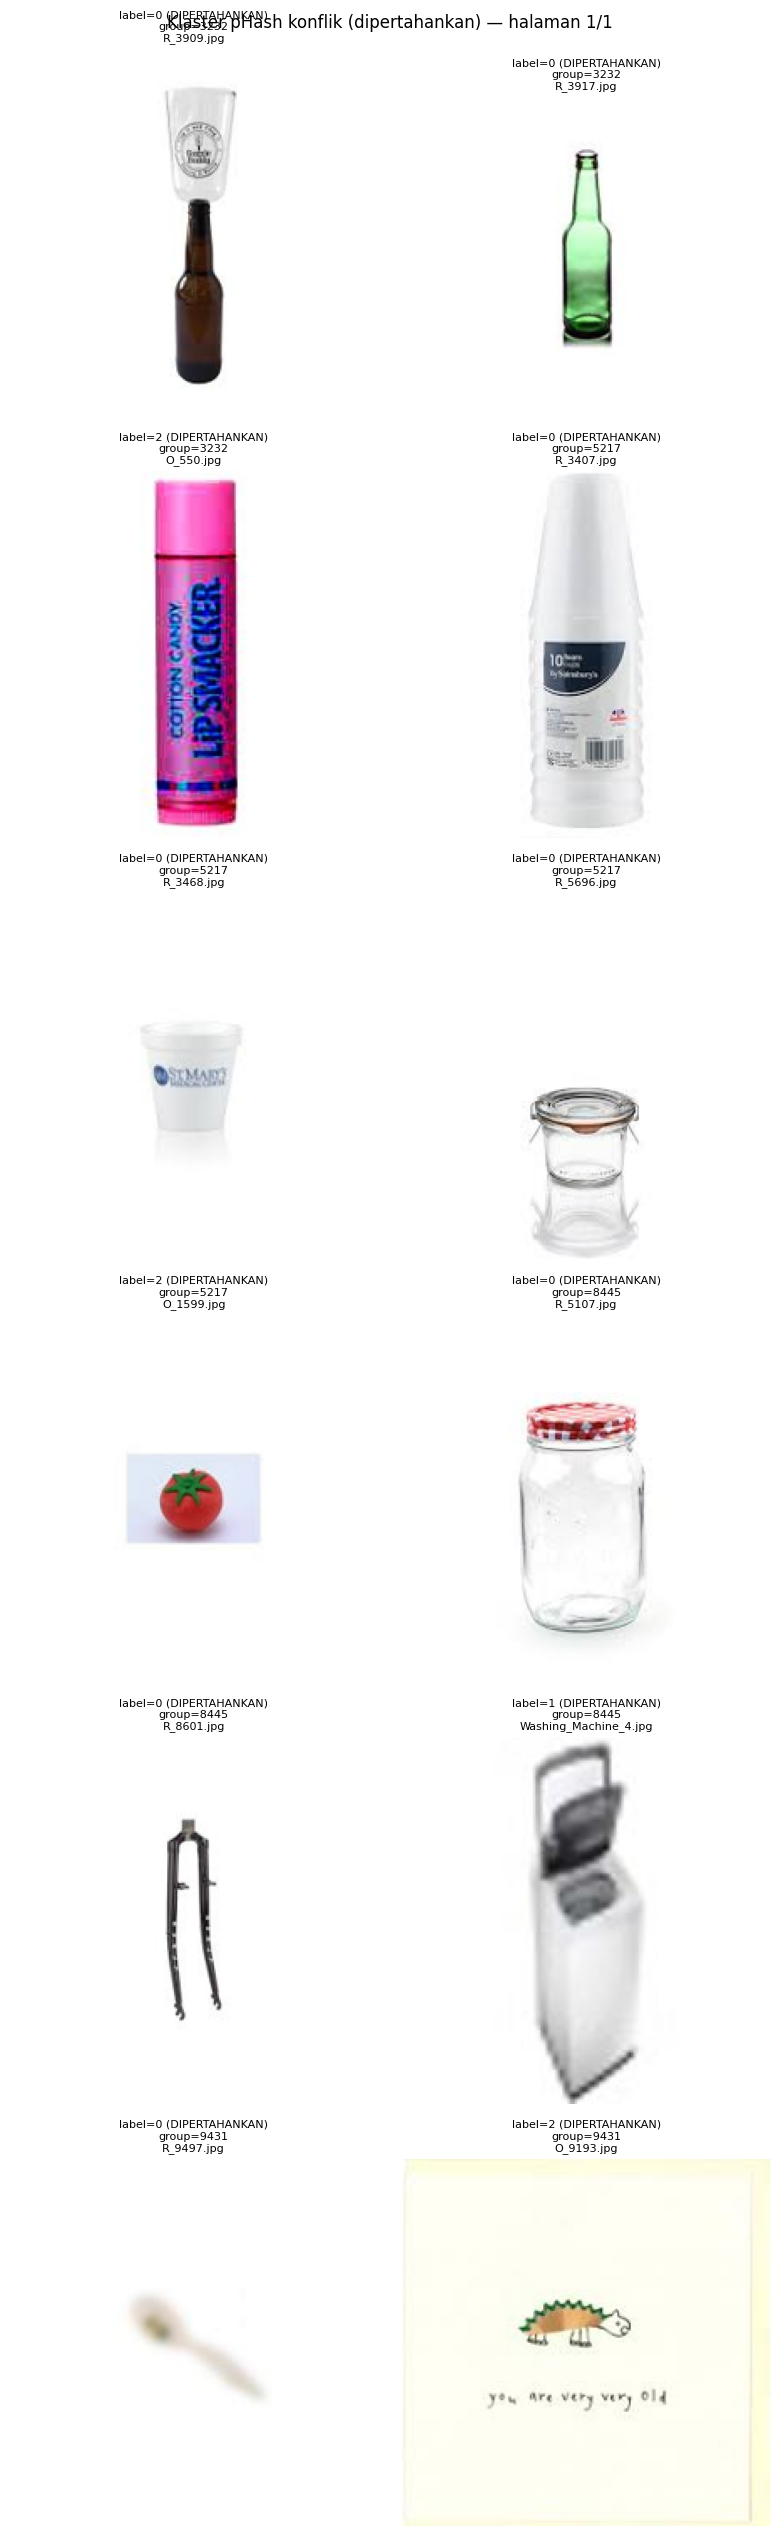

In [13]:
def render_contact_sheet(rows, title, save_path, thumb_size=(220, 220), cols=2):
    n = len(rows)
    if n == 0:
        print(f"({title}: tidak ada gambar)")
        return
    n_rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(n_rows, cols, figsize=(cols * 4, n_rows * 4.3))
    axes = np.array(axes).reshape(-1)
    for ax, r in zip(axes, rows):
        try:
            with Image.open(r["path"]) as im:
                im = im.convert("RGB")
                im.thumbnail(thumb_size)
                ax.imshow(im)
        except Exception as e:
            ax.text(0.5, 0.5, f"gagal load:\n{e}", ha="center", va="center", fontsize=8)
        ax.set_title(r["caption"], fontsize=8)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for stale_sheet in REVIEW_ROOT.glob("perceptual_conflicts_kept_contact_sheet_*.png"):
    stale_sheet.unlink()

sheet_df = perceptual_conflicts_df.sort_values(["group_id", "original_path"])
sheet_items = [
    {"path": r.original_path, "caption": f"label={r.label} (DIPERTAHANKAN)\ngroup={r.group_id}\n{Path(r.original_path).name}"}
    for r in sheet_df.itertuples(index=False)
]
PAGE_SIZE = 20
n_pages = max(1, (len(sheet_items) + PAGE_SIZE - 1) // PAGE_SIZE)
for page in range(n_pages):
    page_items = sheet_items[page * PAGE_SIZE: (page + 1) * PAGE_SIZE]
    save_path = REVIEW_ROOT / f"perceptual_conflicts_kept_contact_sheet_{page + 1}.png"
    render_contact_sheet(page_items, f"Klaster pHash konflik (dipertahankan) — halaman {page + 1}/{n_pages}", save_path)


arsipkan kandidat exclusion:   0%|          | 0/4 [00:00<?, ?it/s]

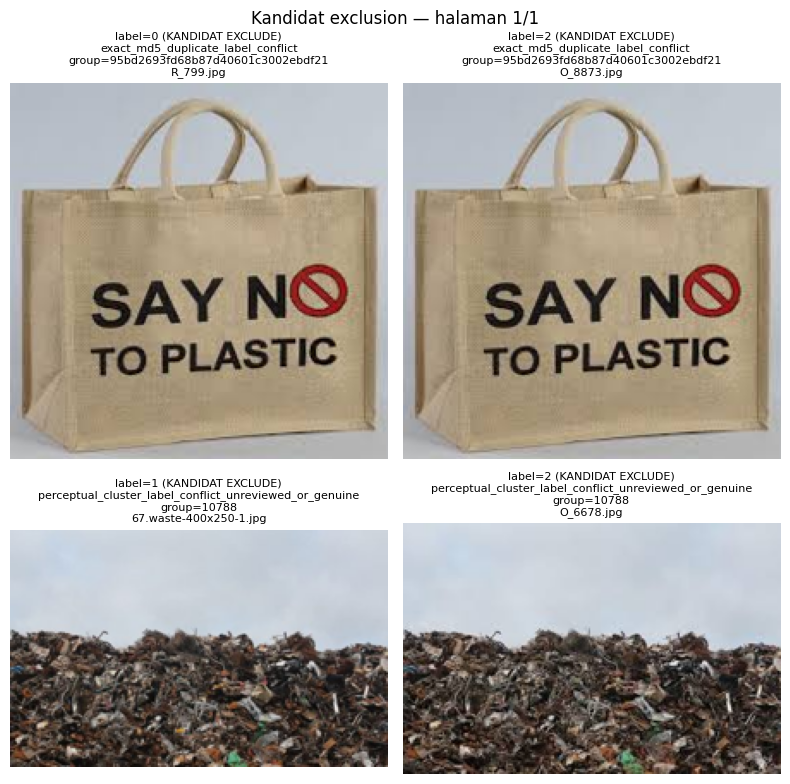

4 gambar disalin ke /content/drive/MyDrive/Big Data Challenge - Satria Data 2026/Preprocessing_Output/review/candidate_exclusions, menunggu CONFIRM_EXCLUSIONS


In [14]:
candidate_exclusions_df = pd.concat(
    [exact_dup_conflicts_df, genuine_perceptual_conflicts_df], ignore_index=True,
)

CANDIDATE_REVIEW_DIR = REVIEW_ROOT / "candidate_exclusions"
reset_dir(CANDIDATE_REVIEW_DIR)  # bersihkan sisa run sebelumnya dulu, supaya tidak menumpuk
for stale_sheet in REVIEW_ROOT.glob("candidate_exclusions_contact_sheet_*.png"):
    stale_sheet.unlink()

candidate_archived_rows = []
for row in tqdm(candidate_exclusions_df.itertuples(index=False), total=len(candidate_exclusions_df),
                 desc="arsipkan kandidat exclusion"):
    src = Path(row.original_path)
    dest = CANDIDATE_REVIEW_DIR / f"label{row.label}__{row.reason}__{src.name}"
    shutil.copy2(src, dest)
    candidate_archived_rows.append({
        "original_path": row.original_path, "label": row.label,
        "group_id": row.group_id, "reason": row.reason, "archived_copy_path": str(dest),
    })

candidate_archived_df = pd.DataFrame(candidate_archived_rows)
candidate_archived_df.to_csv(MANIFEST_DIR / "candidate_exclusions_pending_review.csv", index=False)

if len(candidate_archived_df) > 0:
    sheet_df_candidate = candidate_archived_df.sort_values(["reason", "group_id", "original_path"])
    sheet_items_candidate = [
        {"path": r.original_path, "caption": f"label={r.label} (KANDIDAT EXCLUDE)\n{r.reason}\ngroup={r.group_id}\n{Path(r.original_path).name}"}
        for r in sheet_df_candidate.itertuples(index=False)
    ]
    PAGE_SIZE = 20
    n_pages = max(1, (len(sheet_items_candidate) + PAGE_SIZE - 1) // PAGE_SIZE)
    for page in range(n_pages):
        page_items = sheet_items_candidate[page * PAGE_SIZE: (page + 1) * PAGE_SIZE]
        save_path = REVIEW_ROOT / f"candidate_exclusions_contact_sheet_{page + 1}.png"
        render_contact_sheet(page_items, f"Kandidat exclusion — halaman {page + 1}/{n_pages}", save_path)
print(f"{len(candidate_archived_df)} gambar disalin ke {CANDIDATE_REVIEW_DIR}, menunggu CONFIRM_EXCLUSIONS")


**STOP — review dulu sebelum lanjut** (kalau ada gambar di contact sheet di atas). Kalau sudah
yakin, set `CONFIRM_EXCLUSIONS = True` di sel Config paling atas lalu jalankan ulang dari sel ini.


In [15]:
assert CONFIRM_EXCLUSIONS, (
    "Review dulu gambar di REVIEW_ROOT/candidate_exclusions & contact sheet di atas (kalau ada). "
    "Set CONFIRM_EXCLUSIONS = True di sel Config paling atas setelah yakin, lalu jalankan ulang "
    "notebook ini dari sel Config (atau cukup dari sel ini)."
)

candidate_exclusion_mask = raw_df["original_path"].isin(candidate_exclusions_df["original_path"])
kept_df = raw_df[~candidate_exclusion_mask].copy().reset_index(drop=True)
print(f"Dikonfirmasi manual: {len(raw_df)} -> {len(kept_df)} gambar "
      f"({int(candidate_exclusion_mask.sum())} gambar dikeluarkan (byte-identical konflik + "
      f"perceptual belum/tidak lolos review), TETAP tersimpan utuh di {CANDIDATE_REVIEW_DIR}; "
      f"{len(perceptual_conflicts_df)} gambar klaster pHash false-positive (whitelist) DIPERTAHANKAN di training)")

dedup_report = pd.concat([
    kept_df.assign(status="kept"),
    raw_df[candidate_exclusion_mask].assign(status="excluded_label_conflict"),
], ignore_index=True)[["original_path", "label", "dup_cluster_id", "status"]]
dedup_report.to_csv(MANIFEST_DIR / "dedup_report.csv", index=False)

with open(MANIFEST_DIR / "dedup_threshold_decision.json", "w") as f:
    json.dump({
        "phash_hamming_dup_threshold": PHASH_HAMMING_DUP_THRESHOLD,
        "borderline_range": [PHASH_BORDERLINE_LO, PHASH_BORDERLINE_HI],
        "review_decision": THRESHOLD_REVIEW_DECISION,
        "review_note": THRESHOLD_REVIEW_NOTE,
        "reviewed_false_positive_groups": sorted(REVIEWED_FALSE_POSITIVE_GROUPS),
        "images_excluded_label_conflict": int(candidate_exclusion_mask.sum()),
        "images_perceptual_conflict_kept_as_false_positive": int(len(perceptual_conflicts_df)),
        "clusters_perceptual_conflict_kept_as_false_positive": len(REVIEWED_FALSE_POSITIVE_GROUPS),
        "deviation_from_prd_6_1": (
            "PRD 6.1 literally says exclude all images in any label-conflicting cluster. Manual, "
            "per-group review of the contact sheets showed SOME perceptual (pHash) conflicting "
            "clusters are hash false-positives between genuinely unrelated objects sharing a plain "
            "background (e.g. tomato vs plastic cup) -- those specific groups, listed in "
            "reviewed_false_positive_groups, are kept with their original labels and un-clustered. "
            "Any other conflicting cluster (unreviewed, or reviewed and found to be a genuine "
            "near-duplicate/mislabel, e.g. group 10788's near-identical waste-pile photos filed "
            "under two different classes) is NOT assumed false-positive by default and still goes "
            "through the CONFIRM_EXCLUSIONS gate, same as byte-identical label conflicts."
        ),
        "confirmed_by_human": CONFIRM_EXCLUSIONS,
    }, f, indent=2)


Dikonfirmasi manual: 26464 -> 26462 gambar (2 gambar dikeluarkan (byte-identical konflik + perceptual belum/tidak lolos review), TETAP tersimpan utuh di /content/drive/MyDrive/Big Data Challenge - Satria Data 2026/Preprocessing_Output/review/candidate_exclusions; 12 gambar klaster pHash false-positive (whitelist) DIPERTAHANKAN di training)


## Langkah 5 — Resize master + penamaan ulang numerik kanonis (PRD §6.2)

Satu-satunya transformasi gambar di seluruh pipeline. Setiap gambar yang lolos mendapat integer
sekuensial `image_id` (0..N-1). Diproses **paralel dari salinan lokal** (Langkah 1.5, bukan baca
Drive lagi) dengan timeout per gambar (kalau ada file bermasalah/lambat, dicatat & dilewati, tidak
membekukan seluruh proses seperti sebelumnya) dan resumable (gambar yang sudah pernah diproses
dilewati kalau notebook di-restart). Hasil ditulis ke disk lokal dulu, baru di-sync SEKALI ke
Google Drive di akhir (bulk, jauh lebih stabil daripada 26 ribu tulis kecil satu-satu ke Drive).


In [16]:
def resize_per_rule(im: Image.Image) -> Image.Image:
    w, h = im.size
    if min(w, h) > RESIZE_SHORT_SIDE_CAP:
        if w < h:
            new_w = RESIZE_SHORT_SIDE_CAP
            new_h = round(h * (RESIZE_SHORT_SIDE_CAP / w))
        else:
            new_h = RESIZE_SHORT_SIDE_CAP
            new_w = round(w * (RESIZE_SHORT_SIDE_CAP / h))
        return im.resize((new_w, new_h), Image.LANCZOS)
    return im  # dimensi asli dipertahankan, tidak pernah di-upscale


RESIZE_TIMEOUT_SECONDS = 60  # per gambar -- generous karena cuma disk lokal, harusnya selesai <1 detik

kept_df = kept_df.sort_values("original_path").reset_index(drop=True)
kept_df["image_id"] = np.arange(len(kept_df), dtype=np.int64)


def resize_and_save_one(row):
    local_out_path = LOCAL_PROCESSED_ROOT / f"{row.image_id}.jpg"
    if local_out_path.exists() and local_out_path.stat().st_size > 0:
        # sudah diproses run sebelumnya (resumable) -- rekonstruksi metadata dari file yang sudah
        # ada (baca cepat, tidak resize ulang), BUKAN return None begitu saja supaya manifest tetap
        # lengkap untuk semua gambar walau proses sempat berhenti & dilanjut lagi.
        with Image.open(row.local_path) as src_im:
            orig_w, orig_h = src_im.size
        with Image.open(local_out_path) as out_im:
            new_w, new_h = out_im.size
        return {
            "image_id": int(row.image_id), "original_path": row.original_path,
            "orig_width": orig_w, "orig_height": orig_h,
            "new_width": new_w, "new_height": new_h,
            "output_md5": file_md5(local_out_path),
        }
    with Image.open(row.local_path) as im:
        im = im.convert("RGB")
        orig_w, orig_h = im.size
        out_im = resize_per_rule(im)
        new_w, new_h = out_im.size
        # EXIF otomatis hilang: convert('RGB') + save() baru tidak membawa chunk EXIF sumber.
        out_im.save(local_out_path, format="JPEG", quality=JPEG_QUALITY)
    return {
        "image_id": int(row.image_id),
        "original_path": row.original_path,
        "orig_width": orig_w,
        "orig_height": orig_h,
        "new_width": new_w,
        "new_height": new_h,
        "output_md5": file_md5(local_out_path),
    }


manifest_rows = []
resize_errors = []
rows = list(kept_df.itertuples(index=False))
with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(resize_and_save_one, row): row for row in rows}
    for future in tqdm(list(futures), total=len(futures), desc=f"resize+rename lokal ({N_WORKERS} workers)"):
        row = futures[future]
        try:
            result = future.result(timeout=RESIZE_TIMEOUT_SECONDS)
            if result is not None:
                manifest_rows.append(result)
        except Exception as e:
            resize_errors.append({
                "image_id": int(row.image_id), "original_path": row.original_path, "error": str(e),
            })

if resize_errors:
    pd.DataFrame(resize_errors).to_csv(MANIFEST_DIR / "resize_errors.csv", index=False)
    print(f"PERINGATAN: {len(resize_errors)} gambar gagal/timeout diproses -- dilewati, lihat resize_errors.csv")

manifest_df = pd.DataFrame(manifest_rows)
print(f"Resize selesai: {len(manifest_df)} gambar kanonis tersimpan di disk lokal: {LOCAL_PROCESSED_ROOT}")


resize+rename lokal (64 workers):   0%|          | 0/26462 [00:00<?, ?it/s]

Resize selesai: 26462 gambar kanonis tersimpan di disk lokal: /content/local_staging/processed


### Sync hasil resize ke Google Drive (sekali, bulk, paralel)


In [17]:
sync_pairs = [
    (str(p), str(PROCESSED_ROOT / p.name)) for p in sorted(LOCAL_PROCESSED_ROOT.glob("*.jpg"))
]
sync_errors = parallel_copy(sync_pairs, desc="sync processed ke Drive", per_file_timeout=60)

if sync_errors:
    pd.DataFrame(sync_errors).to_csv(MANIFEST_DIR / "drive_sync_errors.csv", index=False)
    print(f"PERINGATAN: {len(sync_errors)} file gagal di-sync ke Drive -- lihat drive_sync_errors.csv "
          f"(coba jalankan ulang sel ini, biasanya karena Drive lagi lambat sesaat)")

print(f"Sync selesai: {len(sync_pairs) - len(sync_errors)}/{len(sync_pairs)} gambar kanonis ada di Drive: {PROCESSED_ROOT}")


sync processed ke Drive (64 workers):   0%|          | 0/26462 [00:00<?, ?it/s]

Sync selesai: 26462/26462 gambar kanonis ada di Drive: /content/drive/MyDrive/Big Data Challenge - Satria Data 2026/Preprocessing_Output/processed


In [18]:
pip_freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout

preprocessing_manifest = {
    "resize_rule": RESIZE_RULE_TEXT,
    "resize_short_side_cap": RESIZE_SHORT_SIDE_CAP,
    "jpeg_quality": JPEG_QUALITY,
    "library_versions": {
        "python": sys.version,
        "pillow": Image.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "imagehash": imagehash.__version__,
    },
    "pip_freeze_excerpt": pip_freeze,
    "n_images": int(len(manifest_df)),
    "per_image": manifest_df.to_dict(orient="records"),
}
with open(MANIFEST_DIR / "preprocessing_manifest.json", "w") as f:
    json.dump(preprocessing_manifest, f, indent=2)

# Audit-only: image_id -> path relatif asli. TIDAK PERNAH dibaca oleh Dataset/DataLoader mana pun (PRD §6.2, §8).
original_filename_map = {
    int(r.image_id): r.original_path for r in kept_df.itertuples(index=False)
}
with open(MANIFEST_DIR / "original_filename_map.json", "w") as f:
    json.dump(original_filename_map, f, indent=2)

print("Manifest tersimpan di Google Drive:", MANIFEST_DIR)


Manifest tersimpan di Google Drive: /content/drive/MyDrive/Big Data Challenge - Satria Data 2026/Preprocessing_Output/manifests


## Langkah 6 — Pembagian fold (single source of truth, PRD §6.3)

`StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)`, `y=label`,
`groups=dup_cluster_id` (gambar singleton adalah grupnya sendiri). Dibuat SEKALI SAJA; tidak
pernah dibuat ulang; tidak ada anggota tim yang boleh split ulang secara lokal.


In [19]:
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_col = np.full(len(kept_df), -1, dtype=np.int64)
X_dummy = np.zeros(len(kept_df))
for fold_idx, (_, val_idx) in enumerate(
    sgkf.split(X_dummy, kept_df["label"].values, groups=kept_df["dup_cluster_id"].values)
):
    fold_col[val_idx] = fold_idx

assert (fold_col >= 0).all(), "setiap gambar harus mendapat fold"
kept_df["fold"] = fold_col

fold_assignment = kept_df[["image_id", "label", "fold"]].sort_values("image_id").reset_index(drop=True)
fold_assignment.to_csv(MANIFEST_DIR / "fold_assignment.csv", index=False)

print(fold_assignment.groupby(["fold", "label"]).size().unstack(fill_value=0))


label     0    1     2
fold                  
0      2000  782  2506
1      2002  792  2514
2      1998  782  2506
3      1996  792  2502
4      1993  782  2515


## Langkah 7 — Sanity check


In [20]:
assert fold_assignment["image_id"].is_unique
assert set(fold_assignment["image_id"]) == set(range(len(fold_assignment)))
assert fold_assignment["fold"].nunique() == N_SPLITS
assert fold_assignment["label"].isin([0, 1, 2]).all()

# tidak ada dup_cluster_id yang terpecah ke dua fold berbeda (kontrak StratifiedGroupKFold)
cluster_fold_counts = kept_df.groupby("dup_cluster_id")["fold"].nunique()
assert (cluster_fold_counts == 1).all(), "ada klaster duplikat yang terpecah lintas fold"

# nol akses folder test/ di mana pun dalam notebook ini
assert "test" not in RESIZE_RULE_TEXT.lower()
print("Semua sanity check NB01 lolos.")
print(fold_assignment["label"].value_counts(normalize=True).sort_index())


Semua sanity check NB01 lolos.
label
0    0.377485
1    0.148515
2    0.474000
Name: proportion, dtype: float64


## Langkah 8 — Publish sebagai Kaggle Dataset privat `bdc2026-master-data`

Karena notebook training (02a-02d) dan NB04 berjalan di Kaggle GPU sementara notebook ini berjalan
di Colab, output yang sudah tersimpan di Google Drive perlu dipublikasikan sebagai Kaggle Dataset
versi supaya bisa diakses lintas platform. Membungkus `PROCESSED_ROOT/*.jpg`,
`fold_assignment.csv`, `preprocessing_manifest.json`, `dedup_report.csv`,
`original_filename_map.json`. Setiap notebook 02x memin VERSION dataset hasil publish ini di sel
`CONFIG` masing-masing (PRD §6.3).

**PENTING soal API key Kaggle**: JANGAN PERNAH menuliskan/paste API key Kaggle langsung di sel
notebook manapun — notebook ini ikut ter-push ke GitHub, dan sekali sebuah secret masuk git history
itu tetap ada di sana selamanya walau baris itu dihapus belakangan. Simpan key di **Colab Secrets**
sekali saja (ikon kunci di sidebar kiri Colab -> "Add new secret" -> nama `KAGGLE_KEY`, isi
value-nya dengan API key dari kaggle.com/settings -> Create New Token), baru jalankan sel di
bawah — key-nya dibaca langsung dari secret manager, tidak pernah tercetak atau tersimpan di isi
notebook.


In [24]:
KAGGLE_USERNAME = "lolyamelia"  # dipakai untuk membentuk dataset id "username/slug", bukan untuk autentikasi
KAGGLE_DATASET_SLUG = "bdc2026-master-data"

from google.colab import userdata

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)
# PENTING: token Kaggle format baru (mulai dengan "KGAT_") disimpan sebagai file access_token
# polos, BUKAN kaggle.json lama (username+key JSON) -- format lama itu tidak cocok dengan token
# KGAT_ dan menyebabkan autentikasi gagal (kelihatan seperti "dataset sudah ada" padahal
# sebenarnya 401/403 di baliknya).
access_token_path = kaggle_dir / "access_token"
access_token_path.write_text(userdata.get("KAGGLE_KEY"))
access_token_path.chmod(0o600)
print("access_token dibuat dari Colab Secret KAGGLE_KEY (key tidak pernah tercetak/tersimpan di notebook).")

# Tes koneksi dulu sebelum upload beneran -- harus muncul daftar dataset tanpa error 401/403.
test_result = subprocess.run(["kaggle", "datasets", "list", "-m"])
if test_result.returncode != 0:
    raise RuntimeError("Autentikasi Kaggle gagal -- cek lagi isi Colab Secret KAGGLE_KEY (harus token KGAT_... yang masih berlaku).")

# PENTING: JANGAN publish langsung dari PREPROCESSING_OUTPUT_ROOT (Drive). Kaggle CLI mem-zip
# seluruh isi folder itu sendiri, dan membaca ribuan file .jpg kanonis satu-per-satu lewat Drive
# FUSE mount sangat lambat (bottleneck I/O yang sama seperti yang kita hindari di Langkah 5 --
# bedanya di sini CLI kaggle yang melakukan baca file-nya, jadi tidak bisa diparalelkan dari sisi
# kita). Susun dulu payload publish di disk lokal Colab (SSD /content), baru upload dari situ.
LOCAL_PUBLISH_ROOT = LOCAL_STAGING_ROOT / "kaggle_publish"
LOCAL_PUBLISH_ROOT.mkdir(parents=True, exist_ok=True)

local_publish_processed = LOCAL_PUBLISH_ROOT / "processed"
if not local_publish_processed.exists():
    # rename, bukan copy: sama-sama di disk lokal /content jadi ini instan (tidak menyalin byte
    # sama sekali), dan LOCAL_PROCESSED_ROOT tidak dipakai lagi setelah titik ini.
    LOCAL_PROCESSED_ROOT.rename(local_publish_processed)

local_publish_manifests = LOCAL_PUBLISH_ROOT / "manifests"
local_publish_manifests.mkdir(exist_ok=True)
for f in MANIFEST_DIR.glob("*"):
    shutil.copy2(f, local_publish_manifests / f.name)

dataset_meta = {
    "title": KAGGLE_DATASET_SLUG,
    "id": f"{KAGGLE_USERNAME}/{KAGGLE_DATASET_SLUG}",
    "licenses": [{"name": "CC0-1.0"}],
}
with open(LOCAL_PUBLISH_ROOT / "dataset-metadata.json", "w") as f:
    json.dump(dataset_meta, f, indent=2)

def upload_to_kaggle(path, dataset_id, version_message="update"):
    # coba publish pertama kali dulu; kalau dataset sudah ada, otomatis fallback ke version --
    # tidak perlu pilih manual tiap kali notebook ini di-run ulang.
    #
    # SENGAJA tidak pakai capture_output=True: itu bikin output (termasuk progress bar tqdm
    # bawaan kaggle CLI untuk zip/upload) tertahan sampai proses selesai baru muncul semua
    # sekaligus. Tanpa capture_output, output mengalir langsung ke cell secara live.
    print(f"Mengunggah ke Kaggle: {dataset_id} ...")
    create_result = subprocess.run(["kaggle", "datasets", "create", "-p", str(path), "-r", "zip"])
    if create_result.returncode == 0:
        print(f"Publish PERTAMA KALI berhasil: {dataset_id} (VERSION 1)")
        return

    print("'datasets create' gagal (kemungkinan dataset sudah ada) -- coba 'datasets version'...")
    version_result = subprocess.run(
        ["kaggle", "datasets", "version", "-p", str(path), "-m", version_message, "-r", "zip"]
    )
    if version_result.returncode != 0:
        raise RuntimeError("Upload ke Kaggle gagal (create maupun version). Lihat log di atas.")
    print(f"Versi baru berhasil di-upload: {dataset_id}")


upload_to_kaggle(
    LOCAL_PUBLISH_ROOT,
    f"{KAGGLE_USERNAME}/{KAGGLE_DATASET_SLUG}",
    version_message=f"update @ {pd.Timestamp.now(tz='UTC').isoformat()}",
)
print("Cek halaman dataset di kaggle.com untuk lihat nomor VERSION, lalu catat di sel CONFIG setiap notebook 02x.")


access_token dibuat dari Colab Secret KAGGLE_KEY (key tidak pernah tercetak/tersimpan di notebook).
Mengunggah ke Kaggle: lolyamelia/bdc2026-master-data ...
Publish PERTAMA KALI berhasil: lolyamelia/bdc2026-master-data (VERSION 1)
Cek halaman dataset di kaggle.com untuk lihat nomor VERSION, lalu catat di sel CONFIG setiap notebook 02x.
